# Superspreading Signature Detection

This notebook detects node-level superspreading signatures in a temporal cluster-transition network. Each node is a cluster of genetically close and temporally proximate SARS-CoV-2 sequences, defined in overlapping 3-week windows; below, every other window is retained so the working graph advances in 2-week steps. Directed edges link clusters in adjacent retained windows and are weighted by the number of sequences shared between the source and target clusters.

The goal is not to prove that a specific exposure event occurred. Instead, the notebook labels network nodes whose local amplification, onward continuity, downstream branching, or socio-geodemographic mixing look unusual relative to other nodes observed in the same time window. The labels are review signatures, not confirmed transmission events.

## Method Rationale

The upstream clustering dataset uses overlapping 3-week windows advanced in 1-week increments. This notebook keeps every other original window after construction, so retained node windows are 2 weeks apart but still derive from overlapping 3-week sequence windows.

The overlapping-window design intentionally allows the same sequence to appear in consecutive retained windows. When a sequence is present in two adjacent retained windows and its assigned cluster changes, that shared sequence provides evidence of continuity from one node to the next. Edge weights, `in_strength`, and `out_strength` therefore measure observed overlap and window carry-over, not direct transmission counts.

The signature detection uses three complementary dimensions:

1. **Local amplification:** a node has high burden and excess size relative to incoming overlap. The core score combines window percentiles of `log_cluster_size`, `log_excess_over_upstream` and the bounded absolute `novelty_fraction`, then the composite score is ranked within `window_idx` for screening.
2. **Onward dissemination:** a node passes shared sequences forward, branches into multiple successors, or has an even downstream edge-weight distribution. Low downstream expansion for `contained_burst` is ranked among nodes with observed onward spread only.
3. **Socio-geodemographic diversity:** a node has high observed normalised entropy across available demographic/geographic categories. This is used for the `diverse_population_broadcaster` onward label.

Candidate detection uses within-window thresholds for the main screen rather than lifecycle-stratified thresholds. Lifecycle-stratified percentiles and `window_lifecycle_n` are retained as diagnostics, because small lifecycle strata can make percentile ranks unstable. Candidate SSE-like nodes also require at least 6 sampled sequences in the node-cluster; smaller high-novelty clusters are treated as introduction/novelty signals rather than default SSE-like candidates.

Censoring matters. Nodes at the beginning or end of the full dataset, or at the first/last window of a VOC epoch, have uncertain origins or onward spread. The categories retain those nodes but add a censoring note so they can be filtered during sensitivity checks.

## Setup

The notebook is designed to run from either the repository root or the `sse_detection/` folder. SSE-pipeline statistical helpers live in `sse_detection/lib/stats.py` (general helpers in `utils/stats.py`); notebook cells focus on orchestration and interpretation.


In [1]:
from collections import defaultdict
from pathlib import Path
import sys
import importlib

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import data as ld  # noqa: E402
from sse_detection import lib as sselib  # noqa: E402E402

# Reload local package after editing source files
importlib.reload(ld)
importlib.reload(sselib)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_SEED = 42
N_ENTROPY_DRAWS = 1000

## Load Sequence-Level Analysis Data

The raw windows are overlapping 3-week windows stepped weekly. This notebook asks `utils.data.load_analysis_columns(..., window_stride=2)` to keep alternate windows by sorted-window position and reindex them, giving a less redundant 2-week graph step while preserving overlap between adjacent retained windows.


In [2]:
columns = [
    "window_id",
    "window_idx",
    "wn_mid_date",
    "cluster_id",
    "cluster_size",
    "cluster_n_datazones",
    "cluster_duration_days",
    "dz_urban_rural_class",
    "dz_health_board",
    "dz_local_authority",
    "datazone",
    "age_band",
    "sex",
    "is_female",
    "dz_simd_quintile",
    "who_voc",
    "clade",
    "dz_7d_test_positivity",
    "wn_positive_tests",
    "wn_prop_sequenced",
    "dz_cum_sequences",
    "dz_cum_positive_tests",
    "dz_cum_prop_sequenced",
    "dz_cum_incidence_per_capita",
]

df_filtered = ld.load_analysis_columns(
    columns,
    add_policy=True,
    window_stride=2,
    renumber_windows=True,
)

print(f"Sequence-window rows: {len(df_filtered):,}")
print(f"Unique sequences: {df_filtered['sequence_id'].nunique():,}")
print(f"Unique node-clusters: {df_filtered['cluster_id'].nunique():,}")
print(f"Windows: {df_filtered['window_idx'].min()} to {df_filtered['window_idx'].max()}")

display(df_filtered.head(10))

Sequence-window rows: 401,389
Unique sequences: 272,901
Unique node-clusters: 99,006
Windows: 1 to 67


,sequence_id,dz_cum_incidence_per_capita,dz_7d_test_positivity,cluster_size,cluster_n_datazones,collection_date,dz_cum_prop_sequenced,dz_urban_rural_class,wn_mid_date,window_id,age_band,who_voc,dz_simd_quintile,window_idx,clade,dz_health_board,is_female,cluster_id,wn_positive_tests,sex,wn_prop_sequenced,dz_cum_sequences,dz_local_authority,nextclade_qc,resolution,dz_cum_positive_tests,cluster_duration_days,datazone,pango_lineage,policy_period,policy_period_label,policy_intensity
0,Scotland/CVR3946/2020,0.001350,0.022727,1,1,2020-07-04,1.0,Accessible Small Towns,2020-07-14 12:00:00,W001,45-49,NaN,2,1,20B,Dumfries and Galloway,1.0,W001|B.1.1.369|R0.3|S1,342.0,Female,0.184211,1.0,Dumfries and Galloway,good,0.3,1.0,0,S01007678,B.1.1.369,P2,Route map phase 2,52
1,Scotland/CVR3956/2020,0.001103,0.111111,3,2,2020-07-13,1.0,Remote Rural,2020-07-14 12:00:00,W001,20-24,NaN,4,1,20B,Dumfries and Galloway,1.0,W001|B.1.1.369|R0.3|C2,342.0,Female,0.184211,1.0,Dumfries and Galloway,good,0.3,1.0,5,S01007643,B.1.1.369,P3,Route map phase 3,30
2,Scotland/QEUH-94384C/2020,0.001096,0.076923,1,1,2020-07-13,1.0,Large Urban Areas,2020-07-14 12:00:00,W001,35-39,NaN,5,1,20B,Lanarkshire,0.0,W001|B.1.1.10|R0.3|S0,342.0,Male,0.184211,1.0,North Lanarkshire,good,0.3,1.0,0,S01011703,B.1.1.10,P3,Route map phase 3,30
3,Scotland/QEUH-7A4553/2020,0.001079,0.052632,1,1,2020-07-15,1.0,Large Urban Areas,2020-07-14 12:00:00,W001,50-54,NaN,1,1,20B,Greater Glasgow and Clyde,0.0,W001|B.1.1|R0.3|S2,342.0,Male,0.184211,1.0,Glasgow City,good,0.3,1.0,0,S01010154,B.1.1,P3,Route map phase 3,30
4,Scotland/QEUH-7894C0/2020,0.003663,0.166667,2,1,2020-07-16,1.0,Other Urban Areas,2020-07-14 12:00:00,W001,40-44,NaN,2,1,20A,Fife,1.0,W001|B.1.36|R0.3|C1,342.0,Female,0.184211,2.0,Fife,good,0.3,2.0,0,S01009368,B.1.36,P3,Route map phase 3,30
5,Scotland/CAMC-945B8D/2020,0.002237,0.153846,1,1,2020-07-16,0.5,Accessible Small Towns,2020-07-14 12:00:00,W001,65-69,NaN,5,1,20B,Dumfries and Galloway,1.0,W001|B.1.1.369|R0.3|S3,342.0,Female,0.184211,1.0,Dumfries and Galloway,good,0.3,2.0,0,S01007680,B.1.1.369,P3,Route map phase 3,30
6,Scotland/QEUH-789563/2020,0.003663,0.166667,2,1,2020-07-16,1.0,Other Urban Areas,2020-07-14 12:00:00,W001,40-44,NaN,2,1,20A,Fife,0.0,W001|B.1.36|R0.3|C1,342.0,Male,0.184211,2.0,Fife,good,0.3,2.0,0,S01009368,B.1.36,P3,Route map phase 3,30
7,Scotland/QEUH-87C2F2/2020,0.001253,0.090909,38,30,2020-07-17,1.0,Accessible Rural,2020-07-14 12:00:00,W001,55-59,NaN,3,1,20B,Greater Glasgow and Clyde,0.0,W001|B.1.1.406|R0.3|C1,342.0,Male,0.184211,1.0,Inverclyde,good,0.3,1.0,7,S01010822,B.1.1.406,P3,Route map phase 3,30
8,Scotland/QEUH-755533/2020,0.004141,0.266667,3,2,2020-07-18,0.5,Large Urban Areas,2020-07-14 12:00:00,W001,25-29,NaN,5,1,20B,Lothian,0.0,W001|B.1.1.369|R0.3|C2,342.0,Male,0.184211,2.0,City of Edinburgh,good,0.3,4.0,5,S01008631,B.1.1.369,P3,Route map phase 3,30
9,Scotland/QEUH-7557E2/2020,0.004141,0.266667,3,2,2020-07-18,0.5,Large Urban Areas,2020-07-14 12:00:00,W001,25-29,NaN,5,1,20B,Lothian,1.0,W001|B.1.1.369|R0.3|C2,342.0,Female,0.184211,2.0,City of Edinburgh,good,0.3,4.0,5,S01008631,B.1.1.369,P3,Route map phase 3,30


## Observed and Null-Corrected Mixing Scores

For each socio-demographic variable, `cluster_socio_demo_entropy` attaches observed normalised entropy (`*_entropy_obs`) and a within-window null comparison (`*_entropy_z`). The null draws cluster-sized samples from the category frequencies observed in the same window, so positive z-scores indicate more mixing than expected for the cluster size and window.

The SSE category logic uses the observed normalised entropy columns for `mixing_score`, not the z-scores. This keeps the `diverse_population_broadcaster` label tied to absolute population diversity on a 0-1 scale, while the z-score columns remain available for sensitivity checks and descriptive plots.


In [3]:
ENTROPY_SPECS = [
    ("sex", "sex"),
    ("age_band", "age"),
    ("dz_simd_quintile", "simd"),
    ("dz_health_board", "health_board"),
    ("dz_urban_rural_class", "urban_rural"),
]

for category_col, prefix in ENTROPY_SPECS:
    df_filtered = sselib.cluster_socio_demo_entropy(
        df=df_filtered,
        cluster_col="cluster_id",
        category_col=category_col,
        window_col="window_id",
        n_random=N_ENTROPY_DRAWS,
        random_state=RANDOM_SEED,
        prefix=prefix,
    )

entropy_cols = [col for col in df_filtered.columns if "entropy" in col]
print(f"Attached entropy columns: {len(entropy_cols)}")

Attached entropy columns: 20


## Collapse Rows to Node-Level Cluster Summaries

The raw analysis table is sequence-level, with one row per sequence-window observation. The network analysis needs one row per node-cluster. Summary fields use first/min/max values where the value is node-defined, and counts or modal values where the value is sequence-defined.

The node table also carries observed entropy columns, category-count summaries, policy-period context, lineage/VOC labels, and geography counts needed for interpretation and plotting.


In [4]:
agg = {
    "cluster_size": ("cluster_size", "first"),
    "duration_days": ("cluster_duration_days", "first"),
    "first_collection_date": ("collection_date", "min"),
    "last_collection_date": ("collection_date", "max"),
    
    "who_voc": ("who_voc", "first"),
    "clade": ("clade", "first"),
    "pango_lineage": ("pango_lineage", "first"),
    
    "policy_period": ("policy_period", sselib.safe_mode),
    "n_policy_periods": ("policy_period", "nunique"),
    "policy_period_counts": ("policy_period", sselib.frequencies),

    "cluster_n_datazones": ("cluster_n_datazones", "first"),
    "dz_urban_rural_class": ("dz_urban_rural_class", sselib.safe_mode),
    "urban_rural_class_counts": ("dz_urban_rural_class", sselib.frequencies),
    "health_board": ("dz_health_board", sselib.safe_mode),
    "n_health_boards": ("dz_health_board", "nunique"),
    "health_board_counts": ("dz_health_board", sselib.frequencies),
    "local_authority": ("dz_local_authority", sselib.safe_mode),
    "n_local_authorities": ("dz_local_authority", "nunique"),
    "local_authority_counts": ("dz_local_authority", sselib.frequencies),

    "n_age_bands": ("age_band", "nunique"),
    "age_band_counts": ("age_band", sselib.frequencies),

    "fraction_female": ("is_female", "mean"),
    "sex_counts": ("sex", sselib.frequencies),
    
    "simd_quintile": ("dz_simd_quintile", sselib.safe_mode),
    "n_simd_quintiles": ("dz_simd_quintile", "nunique"),
    "simd_quintile_counts": ("dz_simd_quintile", sselib.frequencies),
    
    "dz_7d_test_positivity": ("dz_7d_test_positivity", "mean"),
    "dz_cum_sequences": ("dz_cum_sequences", "mean"),
    "dz_cum_incidence_per_capita": ("dz_cum_incidence_per_capita", "mean"),
    "dz_cum_positive_tests": ("dz_cum_positive_tests", "mean"),
    "dz_cum_prop_sequenced": ("dz_cum_prop_sequenced", "mean"),
    
    "wn_positive_tests": ("wn_positive_tests", "first"),
    "wn_prop_sequenced": ("wn_prop_sequenced", "first"),
    
    **{col: (col, "first") for col in entropy_cols},
}

cluster_table = (
    df_filtered.groupby(["cluster_id", "window_id", "window_idx", "wn_mid_date"], as_index=False)
    .agg(**agg)
    .sort_values(["window_idx", "cluster_size"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Node-clusters: {len(cluster_table):,}")
display(cluster_table.head(10))

Node-clusters: 99,006


,cluster_id,window_id,window_idx,wn_mid_date,cluster_size,duration_days,first_collection_date,last_collection_date,who_voc,clade,pango_lineage,policy_period,n_policy_periods,policy_period_counts,cluster_n_datazones,dz_urban_rural_class,urban_rural_class_counts,health_board,n_health_boards,health_board_counts,local_authority,n_local_authorities,local_authority_counts,n_age_bands,age_band_counts,fraction_female,sex_counts,simd_quintile,n_simd_quintiles,simd_quintile_counts,dz_7d_test_positivity,dz_cum_sequences,dz_cum_incidence_per_capita,dz_cum_positive_tests,dz_cum_prop_sequenced,wn_positive_tests,wn_prop_sequenced,sex_entropy_obs,sex_entropy_null_mean,sex_entropy_null_sd,sex_entropy_z,age_entropy_obs,age_entropy_null_mean,age_entropy_null_sd,age_entropy_z,simd_entropy_obs,simd_entropy_null_mean,simd_entropy_null_sd,simd_entropy_z,health_board_entropy_obs,health_board_entropy_null_mean,health_board_entropy_null_sd,health_board_entropy_z,urban_rural_entropy_obs,urban_rural_entropy_null_mean,urban_rural_entropy_null_sd,urban_rural_entropy_z
0,W001|B.1.1.406|R0.3|C1,W001,1,2020-07-14 12:00:00,38,7,2020-07-17,2020-07-24,NaN,20B,B.1.1.406,P3,1,P3 (28),30,Other Urban Areas,Other Urban Areas (18); Large Urban Areas (7);...,Lanarkshire,4,Lanarkshire (16); Greater Glasgow and Clyde (1...,North Lanarkshire,7,North Lanarkshire (11); South Lanarkshire (5);...,12,20-24 (5); 55-59 (4); 25-29 (4); 35-39 (4); 15...,0.392857,Male (17); Female (11),2,5,2 (10); 3 (7); 1 (6); 4 (4); 5 (1),0.089309,1.214286,0.001792,1.392857,0.922619,342.0,0.184211,0.966619,0.948494,0.060704,0.298569,0.823584,0.766052,0.050273,1.144390,0.895583,0.927876,0.046981,-0.687361,0.35070,0.518183,0.055029,-3.043573,0.523575,0.596160,0.086800,-0.836232
1,W001|B.1.1.369|R0.3|C2,W001,1,2020-07-14 12:00:00,3,5,2020-07-13,2020-07-18,NaN,20B,B.1.1.369,P3,1,P3 (3),2,Large Urban Areas,Large Urban Areas (2); Remote Rural (1),Lothian,2,Lothian (2); Dumfries and Galloway (1),City of Edinburgh,2,City of Edinburgh (2); Dumfries and Galloway (1),2,25-29 (2); 20-24 (1),0.666667,Female (2); Male (1),5,2,5 (2); 4 (1),0.214815,1.666667,0.003128,3.000000,0.666667,342.0,0.184211,0.918296,0.664846,0.410699,0.617118,0.229574,0.340130,0.087037,-1.270224,0.395488,0.509115,0.183071,-0.620673,0.24119,0.284557,0.118577,-0.365731,0.355245,0.327519,0.193453,0.143325
2,W001|B.1|R0.3|C1,W001,1,2020-07-14 12:00:00,3,2,2020-07-20,2020-07-22,NaN,20C,B.1,P3,1,P3 (3),1,Other Urban Areas,Other Urban Areas (3),Fife,1,Fife (3),Fife,1,Fife (3),2,35-39 (2); 30-34 (1),0.333333,Male (2); Female (1),5,1,5 (3),0.166667,2.333333,0.002631,2.333333,1.000000,342.0,0.184211,0.918296,0.664846,0.410699,0.617118,0.229574,0.340130,0.087037,-1.270224,-0.000000,0.509115,0.183071,-2.780979,-0.00000,0.284557,0.118577,-2.399764,-0.000000,0.327519,0.193453,-1.693016
3,W001|B.1.36|R0.3|C1,W001,1,2020-07-14 12:00:00,2,0,2020-07-16,2020-07-16,NaN,20A,B.1.36,P3,1,P3 (2),1,Other Urban Areas,Other Urban Areas (2),Fife,1,Fife (2),Fife,1,Fife (2),1,40-44 (2),0.500000,Female (1); Male (1),2,1,2 (2),0.166667,2.000000,0.003663,2.000000,1.000000,342.0,0.184211,1.000000,0.470000,0.499349,1.061382,-0.000000,0.223500,0.076998,-2.902676,-0.000000,0.336789,0.177910,-1.893032,-0.00000,0.185693,0.119602,-1.552597,-0.000000,0.233272,0.189373,-1.231817
4,W001|B.1|R0.3|C2,W001,1,2020-07-14 12:00:00,2,0,2020-07-22,2020-07-22,NaN,20A,B.1,P3,1,P3 (1),1,Large Urban Areas,Large Urban Areas (1),Greater Glasgow and Clyde,1,Greater Glasgow and Clyde (1),Glasgow City,1,Glasgow City (1),1,05-09 (1),0.000000,Male (1),4,1,4 (1),0.200000,2.000000,0.002780,3.000000,0.666667,342.0,0.184211,-0.000000,0.000000,0.000000,NaN,-0.000000,0.000000,0.000000,NaN,-0.000000,0.000000,0.000000,NaN,-0.00000,0.000000,0.000000,NaN,-0.000000,0.000000,0.000000,NaN
5,W001|B.1.1.10|R0.3|S0,W001,1,2020-07-14 12:00:00,1,0,2020-07-13,2020-07-13,NaN,20B,B.1.1.10,P3,1,P3 (1),1,Large Urban Areas,Large Urban Areas (1),Lanarkshire,1,Lanarkshire (1),North Lanarkshire,1,North Lanarkshire (1),1,35-

## Build Adjacent-Window Transition Network

For each sequence, we inspect the ordered set of node-clusters it occupies across retained windows. A directed edge is added only when two observations are in adjacent retained windows (`delta == 1`) and the cluster assignment changes. The edge weight is the number of unique sequences supporting that transition.

This produces a conservative continuity graph: it does not infer transmission between all genetically similar clusters; it only records observed overlap in adjacent sliding windows. A node with no outgoing edge is therefore not necessarily epidemiologically terminal; it has no observed adjacent-window successor under this graph definition.


In [5]:
seq_nodes = (
    df_filtered[["sequence_id", "cluster_id", "window_id", "window_idx"]]
    .drop_duplicates()
    .sort_values(["sequence_id", "window_idx"])
)

edge_map: dict[tuple[str, str, object, object, int, int], set[str]] = defaultdict(set)

for sequence_id, group in seq_nodes.groupby("sequence_id", sort=False):
    records = list(
        group[["cluster_id", "window_id", "window_idx"]]
        .itertuples(index=False, name=None)
    )

    for i, (source_node, source_window, source_idx) in enumerate(records):
        for target_node, target_window, target_idx in records[i + 1:]:
            delta = target_idx - source_idx

            if delta == 1 and source_node != target_node:
                edge_key = (
                    source_node,
                    target_node,
                    source_window,
                    target_window,
                    source_idx,
                    target_idx,
                )
                edge_map[edge_key].add(str(sequence_id))
            elif delta > 1:
                break

edge_rows = [
    {
        "source": source,
        "target": target,
        "source_window_id": source_window,
        "target_window_id": target_window,
        "source_window_idx": source_idx,
        "target_window_idx": target_idx,
        "n_shared_sequences": len(shared),
    }
    for (
        source,
        target,
        source_window,
        target_window,
        source_idx,
        target_idx,
    ), shared in edge_map.items()
]

edge_table = pd.DataFrame(
    edge_rows,
    columns=[
        "source",
        "target",
        "source_window_id",
        "target_window_id",
        "source_window_idx",
        "target_window_idx",
        "n_shared_sequences",
    ],
)

if not edge_table.empty:
    edge_table = edge_table.sort_values(
        [
            "source_window_idx",
            "target_window_idx",
            "n_shared_sequences",
            "source",
            "target",
        ],
        ascending=[True, True, False, True, True],
        ignore_index=True,
    )

G_raw = nx.DiGraph()
G_raw.add_nodes_from(cluster_table["cluster_id"])
for row in edge_table.itertuples(index=False):
    G_raw.add_edge(row.source, row.target, weight=row.n_shared_sequences)

components = sorted(
    nx.weakly_connected_components(G_raw),
    key=lambda nodes: (-len(nodes), sorted(nodes)[0]),
)
component_map = {
    node: f"AM{component_idx:05d}"
    for component_idx, nodes in enumerate(components, start=1)
    for node in nodes
}
cluster_table["meta_cluster_id"] = cluster_table["cluster_id"].map(component_map)

print(f"Graph nodes: {G_raw.number_of_nodes():,}")
print(f"Graph edges: {G_raw.number_of_edges():,}")
print(f"Weakly connected components: {len(components):,}")
display(edge_table.head(10))

Graph nodes: 99,006
Graph edges: 41,747
Weakly connected components: 57,354


,source,target,source_window_id,target_window_id,source_window_idx,target_window_idx,n_shared_sequences
0,W001|B.1.1.406|R0.3|C1,W003|B.1.1.406|R0.3|C1,W001,W002,1,2,25
1,W001|B.1|R0.3|C1,W003|B.1|R0.3|C1,W001,W002,1,2,3
2,W001|B.1.1.369|R0.3|C2,W003|B.1.1.369|R0.3|C1,W001,W002,1,2,2
3,W001|B.1.1.170|R0.3|S0,W003|B.1.1.170|R0.3|S0,W001,W002,1,2,1
4,W001|B.1.1.406|R0.3|C1,W003|B.1.1.406|R0.3|C3,W001,W002,1,2,1
5,W001|B.1.1.406|R0.3|C1,W003|B.1.1.406|R0.3|S2,W001,W002,1,2,1
6,W001|B.1.1.406|R0.3|S2,W003|B.1.1.406|R0.3|C3,W001,W002,1,2,1
7,W001|B.1.1.406|R0.3|S3,W003|B.1.1.406|R0.3|S4,W001,W002,1,2,1
8,W001|B.1|R0.3|C2,W003|B.1|R0.3|C2,W001,W002,1,2,1
9,W003|AD.2|R0.3|C1,W005|AD.2|R0.3|C1,W002,W003,2,3,116


## Summarise Meta-Clusters

Weakly connected components are treated as meta-clusters: groups of node-clusters linked by at least one path through adjacent-window overlap. These summaries help distinguish short isolated bursts from persistent lineages that move through many windows.

Meta-clusters are also the unit for the separate weekly growth diagnostic below. They are not the same thing as node-level SSE candidates.


In [6]:
node_summary = (
    cluster_table.groupby("meta_cluster_id", as_index=False)
    .agg(
        n_clusters=("cluster_id", "nunique"),
        n_windows=("window_id", "nunique"),
        first_window_mid_date=("wn_mid_date", "min"),
        last_window_mid_date=("wn_mid_date", "max"),
        max_cluster_size=("cluster_size", "max"),
        max_cluster_n_datazones=("cluster_n_datazones", "max"),
    )
)

seq_meta_long = df_filtered[[
    "sequence_id",
    "collection_date",
    "cluster_id",
    "pango_lineage",
    "who_voc",
    "clade",
]].merge(
    cluster_table[["cluster_id", "meta_cluster_id"]].drop_duplicates(),
    on="cluster_id",
    how="left",
)

seq_meta_long["n_candidate_meta_clusters"] = (
    seq_meta_long.groupby("sequence_id")["meta_cluster_id"].transform("nunique")
)
seq_meta_long["ambiguous_meta_assignment"] = seq_meta_long["n_candidate_meta_clusters"] > 1

sequence_summary = (
    seq_meta_long.groupby("meta_cluster_id", as_index=False)
    .agg(
        n_sequences=("sequence_id", "nunique"),
        first_collection_date=("collection_date", "min"),
        last_collection_date=("collection_date", "max"),
        pango_lineage=("pango_lineage", "first"),
        clade=("clade", "first"),
        who_voc=("who_voc", "first"),
        ambiguous_sequence_assignments=("ambiguous_meta_assignment", "sum"),
    )
)

meta_summary = node_summary.merge(sequence_summary, on="meta_cluster_id", how="left")
meta_summary["duration_days"] = (
    meta_summary["last_collection_date"] - meta_summary["first_collection_date"]
).dt.days
meta_summary = meta_summary.sort_values(
    ["n_sequences", "n_clusters"],
    ascending=[False, False],
).reset_index(drop=True)

print(f"Ambiguous sequence-window assignments: {seq_meta_long['ambiguous_meta_assignment'].sum():,}")
display(meta_summary.head(10))

Ambiguous sequence-window assignments: 0


,meta_cluster_id,n_clusters,n_windows,first_window_mid_date,last_window_mid_date,max_cluster_size,max_cluster_n_datazones,n_sequences,first_collection_date,last_collection_date,pango_lineage,clade,who_voc,ambiguous_sequence_assignments,duration_days
0,AM00002,222,6,2021-11-30 12:00:00,2022-02-08 12:00:00,2666,2014,8184,2021-11-28,2022-01-29,BA.1,21K,Omicron,0,62
1,AM00011,61,3,2021-05-18 12:00:00,2021-06-15 12:00:00,2000,1212,4781,2021-05-19,2021-06-18,AY.4,21J,Delta,0,30
2,AM00001,254,4,2021-06-01 12:00:00,2021-07-13 12:00:00,1087,872,4666,2021-06-02,2021-07-14,AY.4,21J,Delta,0,42
3,AM00004,174,3,2022-04-05 12:00:00,2022-05-03 12:00:00,1119,904,2557,2022-04-04,2022-05-04,BA.2,21L,Omicron,0,30
4,AM00003,190,2,2022-01-11 12:00:00,2022-01-25 12:00:00,1718,1314,2482,2022-01-08,2022-02-03,BA.1.1,21K,Omicron,0,26
5,AM00005,131,4,2021-11-30 12:00:00,2022-01-11 12:00:00,1856,1435,2402,2021-11-29,2022-01-13,BA.1.1,21K,Omicron,0,45
6,AM00014,50,5,2021-11-30 12:00:00,2022-01-25 12:00:00,984,822,2388,2021-11-28,2022-01-15,BA.1.15,21K,Omicron,0,48
7,AM45858,1,1,2022-02-08 12:00:00,2022-02-08 12:00:00,2294,1640,2137,2022-02-07,2022-02-18,BA.2,21L,Omicron,0,11
8,AM00015,49,4,2021-11-30 12:00:00,2022-01-11 12:00:00,814,711,1896,2021-12-02,2022-01-14,BA.1.17.2,21K,Omicron,0,43
9,AM49266,1,1,2022-04-05 12:00:00,2022-04-05 12:00:00,1861,1482,1615,2022-03-26,2022-04-02,BA.2,21L,Omicron,0,7


## Weekly Meta-Cluster Growth Check

The graph categories below are node-level signatures. As a complementary check, `flag_sse` computes weekly alerts within each meta-cluster. First-observed bursts and growth bursts are split because `cc_size_prev == 0` makes `norm_change` a raw-count screen rather than a growth metric.

This weekly flag is deliberately separate from `sse_candidate`. It is a meta-cluster growth alert, not the main node-level superspreading-signature definition.


In [7]:
weekly_growth = sselib.flag_sse(seq_meta_long)
weekly_sse_weeks = weekly_growth.loc[weekly_growth["is_sse"]].sort_values(
    ["sse_flag_type", "norm_change", "new_sequences"],
    ascending=[True, False, False],
)

print(f"Weekly growth rows: {len(weekly_growth):,}")
print(f"Flagged weekly SSE-like alert rows: {len(weekly_sse_weeks):,}")
print(f"  first-observed bursts: {weekly_growth['first_observed_burst'].sum():,}")
print(f"  growth bursts: {weekly_growth['growth_burst'].sum():,}")
display(weekly_sse_weeks.head(10))


Weekly growth rows: 3,226,494
Flagged weekly SSE-like alert rows: 1,779
  first-observed bursts: 907
  growth bursts: 872


,week,new_sequences,meta_cluster_id,clade,cc_size,cc_size_prev,norm_change,first_observed_burst,growth_burst,is_sse,sse_flag_type
2804433,2022-02-07,798,AM45858,21L,798,0.0,798.0,True,False,True,first_observed_burst
2965190,2022-03-21,747,AM49266,21L,747,0.0,747.0,True,False,True,first_observed_burst
955,2022-01-10,389,AM00016,21K,389,0.0,389.0,True,False,True,first_observed_burst
639,2021-05-17,356,AM00011,21J,356,0.0,356.0,True,False,True,first_observed_burst
4235,2021-09-06,291,AM00066,21J,291,0.0,291.0,True,False,True,first_observed_burst
779,2022-01-24,271,AM00013,21K,271,0.0,271.0,True,False,True,first_observed_burst
205,2022-04-04,230,AM00004,21L,230,0.0,230.0,True,False,True,first_observed_burst
46447,2022-03-07,223,AM00674,21L,223,0.0,223.0,True,False,True,first_observed_burst
2725279,2022-01-24,217,AM44343,21K,217,0.0,217.0,True,False,True,first_observed_burst
1246,2021-09-06,210,AM00021,21J,210,0.0,210.0,True,False,True,first_observed_burst


## Score Node-Level Signatures

Incoming edge metrics describe how much observed sequence overlap a node inherited from previous retained windows. Because retained windows still overlap, these metrics are continuity signatures rather than direct onward-transmission counts.

The amplification metrics then separate absolute burden from inherited overlap:

- `log_cluster_size`: log-scaled node size.
- `log_excess_over_upstream`: `log1p(cluster_size) - log1p(in_strength)`.
- `novelty_fraction`: bounded fraction of the node not explained by incoming overlap.

The main `local_amplification_score` averages available `log_cluster_size_pct_window`, `log_excess_over_upstream_pct_window`, and `novelty_fraction` components, then candidate screening ranks this composite within `window_idx`. Candidate detection additionally requires `cluster_size >= 6` by default, so very small high-novelty introductions remain diagnostic but are not labelled candidate SSE-like nodes.

Downstream entropy describes how evenly outgoing overlap is distributed across successors. A single outgoing successor is labelled separately from a genuine dominant branch: `single_successor_chain` means exactly one successor, while `dominant_branch` requires at least two successors with concentrated edge weight. The low-expansion part of `contained_burst` uses `downstream_expansion_proxy_pct_onward_window`, ranked only among nodes with `out_strength > 0`.

The `mixing_score` is the mean of available observed normalised entropy columns (`*_entropy_obs`). It contributes only to the `diverse_population_broadcaster` label when downstream branching and expansion are also high. `onward_dissemination_score` is retained as a display/ranking diagnostic rather than a separate classification rule.


In [8]:
in_metrics = (
    edge_table.groupby("target")
    .agg(
        in_degree=("target", "size"),
        in_strength=("n_shared_sequences", "sum"),
    )
    .reset_index()
    .rename(columns={"target": "cluster_id"})
)

node_stats = cluster_table.merge(in_metrics, on="cluster_id", how="left")

downstream_null = sselib.downstream_edge_entropy(
    edge_df=edge_table,
    source_col="source",
    weight_col="n_shared_sequences",
)

node_stats = node_stats.merge(
    downstream_null.reset_index().rename(columns={"source": "cluster_id"}),
    on="cluster_id",
    how="left",
)

node_stats = sselib.add_sse_node_metrics(node_stats)
node_stats = sselib.categorise_sse_nodes(node_stats)

print(f"SSE-like candidate nodes: {node_stats['sse_candidate'].sum():,} / {len(node_stats):,}")
print("Candidate size floor: cluster_size >= 6 sampled sequences")

SSE-like candidate nodes: 6,907 / 99,006
Candidate size floor: cluster_size >= 6 sampled sequences


## Category Review

The final category has two parts: a role (`putative_birth`, `relay_amplifier`, `merged_relay`, `terminal_sink`, `isolated_burst`, or `unclear_origin`) and an onward dynamic (`contained_burst`, `single_successor_chain`, `dominant_branch`, `multi_branch_seeder`, `multi_branch_expander`, `diverse_population_broadcaster`, `high_volume_onward_spread`, `no_observed_onward_spread`, or `weak_or_ambiguous_onward_spread`).

Rows labelled `not_sse_like` did not pass the amplification screen. Censoring notes should be used when interpreting origin or terminal categories. The `mixing_score` used for the diverse-population label is the mean of available observed normalised socio-demographic entropies, not an entropy z-score.

The candidate review table includes the core score ingredients (`log_cluster_size`, `log_excess_over_upstream`, and `novelty_fraction`), the observed mixing score and count of available components, the lifecycle stratum size, and key graph metrics for manual review.


In [9]:
category_counts = (
    node_stats["sse_category"]
    .value_counts(dropna=False)
    .rename_axis("sse_category")
    .reset_index(name="n_nodes")
)
category_counts["pct_nodes"] = category_counts["n_nodes"] / len(node_stats)

display(category_counts)

,sse_category,n_nodes,pct_nodes
0,not_sse_like,92099,0.930237
1,unclear_origin__contained_burst,2339,0.023625
2,unclear_origin__single_successor_chain,1715,0.017322
3,unclear_origin__dominant_branch,884,0.008929
4,isolated_burst__no_observed_onward_spread,838,0.008464
5,relay_amplifier__contained_burst,285,0.002879
6,terminal_sink__contained_burst,209,0.002111
7,unclear_origin__diverse_population_broadcaster,173,0.001747
8,unclear_origin__multi_branch_expander,145,0.001465
9,unclear_origin__multi_branch_seeder,143,0.001444


In [10]:
role_dynamic_counts = (
    node_stats.loc[node_stats["sse_candidate"]]
    .groupby(["sse_role", "sse_onward_dynamic", "sse_censoring_note"], dropna=False)
    .size()
    .reset_index(name="n_nodes")
    .sort_values("n_nodes", ascending=False)
)

display(role_dynamic_counts)

,sse_role,sse_onward_dynamic,sse_censoring_note,n_nodes
16,unclear_origin,contained_burst,not_censored,2339
23,unclear_origin,single_successor_chain,not_censored,1715
19,unclear_origin,dominant_branch,not_censored,883
0,isolated_burst,no_observed_onward_spread,not_censored,823
9,relay_amplifier,contained_burst,not_censored,285
15,terminal_sink,contained_burst,not_censored,209
17,unclear_origin,diverse_population_broadcaster,not_censored,173
21,unclear_origin,multi_branch_expander,not_censored,145
22,unclear_origin,multi_branch_seeder,not_censored,143
5,putative_birth,contained_burst,not_censored,38


In [11]:
review_cols = [
    "cluster_id",
    "meta_cluster_id",
    "window_idx",
    "wn_mid_date",
    "sse_category",
    "sse_censoring_note",
    "cluster_size",
    "log_cluster_size",
    "log_excess_over_upstream",
    "novelty_fraction",
    "in_strength",
    "out_strength",
    "out_degree",
    "dominant_successor_frac",
    "downstream_entropy_norm",
    "local_amplification_score",
    "local_amplification_score_pct_window",
    "downstream_expansion_proxy_pct_onward_window",
    "onward_dissemination_score",
    "mixing_score",
    "mixing_score_n",
    "diverse_population",
    "window_lifecycle_n",
    "cluster_n_datazones",
    "n_health_boards",
    "n_local_authorities",
    "who_voc",
    "clade",
    "pango_lineage",
    "policy_period",
]
review_cols = [col for col in review_cols if col in node_stats.columns]

candidate_review = (
    node_stats.loc[node_stats["sse_candidate"], review_cols]
    .sort_values(
        ["local_amplification_score", "onward_dissemination_score", "cluster_size"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

display(candidate_review.head(10))

,cluster_id,meta_cluster_id,window_idx,wn_mid_date,sse_category,sse_censoring_note,cluster_size,log_cluster_size,log_excess_over_upstream,novelty_fraction,in_strength,out_strength,out_degree,dominant_successor_frac,downstream_entropy_norm,local_amplification_score,local_amplification_score_pct_window,downstream_expansion_proxy_pct_onward_window,onward_dissemination_score,mixing_score,mixing_score_n,diverse_population,window_lifecycle_n,cluster_n_datazones,n_health_boards,n_local_authorities,who_voc,clade,pango_lineage,policy_period
0,W095|BA.2|R0.3|C1672,AM00114,48,2022-05-03 12:00:00,putative_birth__contained_burst,not_censored,114,4.744932,4.744932,1.0,0.0,6.0,1.0,1.000000,NaN,0.941012,1.000000,0.003817,0.858058,0.911364,5,True,1238,96,12,26,Omicron,21L,BA.2,PR
1,W095|BA.2|R0.3|C2046,AM00114,48,2022-05-03 12:00:00,putative_birth__dominant_branch,not_censored,99,4.605170,4.605170,1.0,0.0,83.0,3.0,0.975904,0.118588,0.940822,0.999715,0.996183,0.962094,0.892984,5,True,1238,87,11,24,Omicron,21L,BA.2,PR
2,W095|BA.2.18|R0.3|C44,AM00217,48,2022-05-03 12:00:00,putative_birth__dominant_branch,not_censored,61,4.127134,4.127134,1.0,0.0,38.0,2.0,0.973684,0.175565,0.940347,0.999431,0.980916,0.954869,0.838785,5,True,1238,51,8,14,Omicron,21L,BA.2.18,PR
3,W095|BA.2.23|R0.3|C219,AM00437,48,2022-05-03 12:00:00,putative_birth__dominant_branch,not_censored,42,3.761200,3.761200,1.0,0.0,37.0,3.0,0.945946,0.225513,0.939968,0.999146,0.997455,0.962379,0.868365,5,True,1238,33,9,16,Omicron,21L,BA.2.23,PR
4,W095|BA.2.8|R0.3|C80,AM52720,48,2022-05-03 12:00:00,isolated_burst__no_observed_onward_spread,not_censored,36,3.610918,3.610918,1.0,0.0,0.0,0.0,NaN,NaN,0.939683,0.998861,NaN,0.388240,0.818638,5,True,1238,33,8,11,Omicron,21L,BA.2.8,PR
5,W095|BA.2.23|R0.3|C170,AM00437,48,2022-05-03 12:00:00,putative_birth__contained_burst,not_censored,34,3.555348,3.555348,1.0,0.0,1.0,1.0,1.000000,NaN,0.939303,0.998576,0.001272,0.821505,0.903562,5,True,1238,30,9,13,Omicron,21L,BA.2.23,PR
6,W095|BA.2|R0.3|C1671,AM02909,48,2022-05-03 12:00:00,putative_birth__contained_burst,not_censored,25,3.258097,3.258097,1.0,0.0,3.0,1.0,1.000000,NaN,0.938259,0.998292,0.013995,0.853751,0.733653,5,True,1238,24,4,6,Omicron,21L,BA.2,PR
7,W095|BA.2.12.1|R0.3|C22,AM00704,48,2022-05-03 12:00:00,putative_birth__dominant_branch,not_censored,24,3.218876,3.218876,1.0,0.0,23.0,3.0,0.869565,0.428027,0.937880,0.998007,0.998728,0.962450,0.831541,5,True,1238,22,8,12,Omicron,22C,BA.2.12.1,PR
8,W095|BA.2.18|R0.3|C39,AM00217,48,2022-05-03 12:00:00,putative_birth__dominant_branch,not_censored,21,3.091042,3.091042,1.0,0.0,12.0,2.0,0.916667,0.413817,0.936219,0.997580,0.978372,0.953694,0.796851,5,True,1238,14,6,7,Omicron,21L,BA.2.18,PR
9,W095|BA.2.9.7|R0.3|C6,AM01353,48,2022-05-03 12:00:00,putative_birth__contained_burst,not_censored,21,3.091042,3.091042,1.0,0.0,7.0,1.0,1.000000,NaN,0.936219,0.997580,0.073155,0.866209,0.712229,5,True,1238,18,4,6,Omicron,21L,BA.2.9.7,PR


## Quick Visual Diagnostic

This plot is deliberately simple: it checks whether the category distribution is dominated by one noisy class and highlights the most common candidate signatures for manual review.

Useful things to look for after changing thresholds are: too many singleton or very small candidates, dominance by `single_successor_chain`, absence or overabundance of `diverse_population_broadcaster`, and categories concentrated in tiny lifecycle strata.


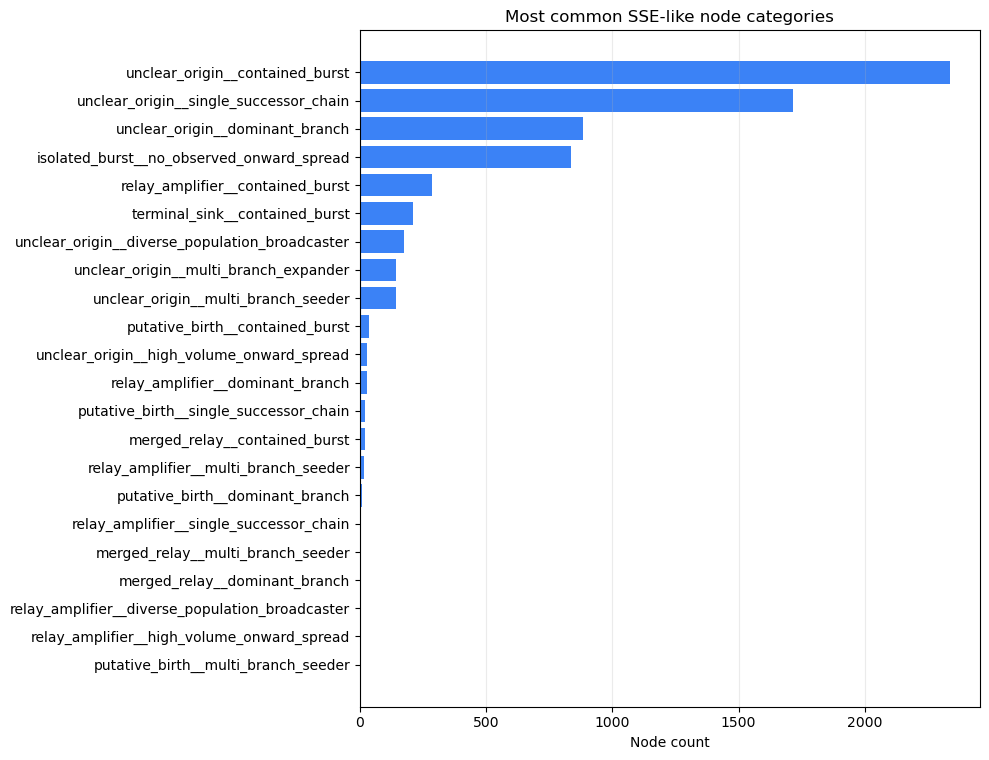

In [12]:
plot_counts = category_counts.query("sse_category != 'not_sse_like'")

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_counts))))
ax.barh(plot_counts["sse_category"], plot_counts["n_nodes"], color="#3B82F6")
ax.invert_yaxis()
ax.set_xlabel("Node count")
ax.set_ylabel("")
ax.set_title("Most common SSE-like node categories")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Objects Produced

The main in-memory outputs are:

- `cluster_table`: one row per node-cluster.
- `edge_table`: directed adjacent-window transition edges with shared-sequence weights.
- `meta_summary`: weakly connected component summaries.
- `weekly_growth`: separate weekly meta-cluster growth diagnostics.
- `node_stats`: node-level metrics, SSE candidate flags, categories, censoring notes, core score components, observed mixing scores, and lifecycle-stratum diagnostics.
- `candidate_review`: ranked candidate node table for inspection.
- `G_raw`: directed adjacent-window cluster transition network.

The companion file `sse_categorise.md` defines the category labels and their intended interpretation.


In [13]:
import gzip
import pickle

OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "sse_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables_to_save = {
    "cluster_table": cluster_table,
    "edge_table": edge_table,
    "meta_summary": meta_summary,
    "weekly_growth": weekly_growth,
    "node_stats": node_stats,
    "candidate_review": candidate_review,
}

saved_outputs = []
for name, table in tables_to_save.items():
    path = OUTPUT_DIR / f"{name}.parquet"
    table.to_parquet(path, index=False)
    saved_outputs.append(
        {
            "object": name,
            "format": "parquet",
            "n_rows": len(table),
            "n_columns": len(table.columns),
            "n_nodes": None,
            "n_edges": None,
            "path": str(path.relative_to(PROJECT_ROOT)),
        }
    )

sse_network = G_raw.copy()
nx.set_node_attributes(sse_network, node_stats.set_index("cluster_id").to_dict("index"))

edge_attr_cols = [col for col in edge_table.columns if col not in {"source", "target"}]
edge_attrs = {
    (row["source"], row["target"]): {col: row[col] for col in edge_attr_cols}
    for row in edge_table.to_dict("records")
}
nx.set_edge_attributes(sse_network, edge_attrs)

network_path = OUTPUT_DIR / "sse_transition_network.gpickle.gz"
with gzip.open(network_path, "wb") as f:
    pickle.dump(sse_network, f, protocol=pickle.HIGHEST_PROTOCOL)

saved_outputs.append(
    {
        "object": "sse_transition_network",
        "format": "gpickle.gz",
        "n_rows": None,
        "n_columns": None,
        "n_nodes": sse_network.number_of_nodes(),
        "n_edges": sse_network.number_of_edges(),
        "path": str(network_path.relative_to(PROJECT_ROOT)),
    }
)

export_manifest = pd.DataFrame(saved_outputs)
export_manifest.to_parquet(OUTPUT_DIR / "export_manifest.parquet", index=False)
display(export_manifest)

,object,format,n_rows,n_columns,n_nodes,n_edges,path
0,cluster_table,parquet,99006.0,58.0,NaN,NaN,sse_detection/sse_outputs/cluster_table.parquet
1,edge_table,parquet,41747.0,7.0,NaN,NaN,sse_detection/sse_outputs/edge_table.parquet
2,meta_summary,parquet,57354.0,15.0,NaN,NaN,sse_detection/sse_outputs/meta_summary.parquet
3,weekly_growth,parquet,3226494.0,11.0,NaN,NaN,sse_detection/sse_outputs/weekly_growth.parquet
4,node_stats,parquet,99006.0,159.0,NaN,NaN,sse_detection/sse_outputs/node_stats.parquet
5,candidate_review,parquet,6907.0,30.0,NaN,NaN,sse_detection/sse_outputs/candidate_review.par...
6,sse_transition_network,gpickle.gz,NaN,NaN,99006.0,41747.0,sse_detection/sse_outputs/sse_transition_netwo...
